# CustomerChurnX - Comprensión exploratoria de datos

## Objetivo

Este notebook desarrolla el análisis exploratorio del dataset oficial para
caracterizar la estructura de las variables, evaluar calidad de datos y
documentar patrones relevantes para el problema de negocio asociado a
predicción de incumplimiento de pago.

El alcance es exclusivamente exploratorio: no se entrenan modelos, no se
imputan valores, no se eliminan registros y no se crean variables
predictivas nuevas. Las anomalías de calidad de datos detectadas (valores
fuera de rango, categorías contaminadas) se **diagnostican y documentan**,
pero no se corrigen aquí; su corrección se ejecuta en la etapa de Feature
Engineering, para mantener este notebook como un diagnóstico auditable del
estado real de los datos.

## Librerías

Las librerías seleccionadas permiten manipulación tabular, pruebas
estadísticas formales y visualización. Se incorpora `scipy.stats` para
pruebas de significancia (Mann-Whitney U, chi-cuadrado) y, de forma
opcional, `statsmodels` para el cálculo de VIF (factor de inflación de la
varianza) en el análisis de multicolinealidad. Se mantiene un conjunto
acotado de dependencias para facilitar reproducibilidad y lectura del
notebook.

In [28]:
from __future__ import annotations

import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("customerchurnx.eda")

In [29]:
!pip install statsmodels

## Configuración

La configuración estandariza el estilo visual de las gráficas y centraliza
constantes del análisis. La variable `Pago_atiempo` se trata como objetivo
porque es la variable supervisada disponible en el dataset oficial. No
existe una columna `churn` en el archivo validado, por lo que no se
inventa ni se deriva una variable con ese nombre.

Se define además `HIGH_CARDINALITY_THRESHOLD`: cualquier columna de tipo
texto cuya proporción de valores únicos supere ese umbral se trata como
cuasi-identificador y se excluye automáticamente del bloque de variables
categóricas nominales (esto reemplaza el parche manual que existía en la
versión anterior del notebook para excluir `fecha_prestamo`).

Las reglas de rango válido y las categorías válidas de `tendencia_ingresos`
se reutilizan del criterio ya aplicado en `Cargar_datos.ipynb`.

In [30]:
DATA_PATH = Path("../Base_de_datos.xlsx - Hoja1.csv")
TARGET_COLUMN = "Pago_atiempo"
IDENTIFIER_COLUMNS: list[str] = []
RANDOM_STATE = 42
HIGH_CARDINALITY_THRESHOLD = 0.90
QUASI_CONSTANT_THRESHOLD = 0.95  # proporcion de la moda a partir de la cual
                                  # una variable se considera cuasi-constante
RANDOM_STATE_NOTE = (
    "RANDOM_STATE se define aqui por convencion de configuracion "
    "compartida con las etapas de Feature Engineering y modelado; "
    "no se usa en este notebook porque el EDA no ejecuta ningun "
    "muestreo ni proceso aleatorio."
)

VALUE_RANGE_RULES = {
    "edad_cliente": (18, 100),
    "puntaje": (0, 100),
    "puntaje_datacredito": (150, 950),
}
VALID_TENDENCIA_CATEGORIES = {"Creciente", "Decreciente", "Estable"}
LEAKAGE_CORRELATION_THRESHOLD = 0.70

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## Carga y validación

Se reutiliza el mismo criterio de "fail fast" aplicado en
`Cargar_datos.ipynb`: si el archivo oficial no existe en la ruta relativa
esperada, la ejecución se detiene de forma explícita en lugar de continuar
con un estado inconsistente.

In [31]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Carga el dataset oficial validando previamente su existencia.

    Si el archivo no se encuentra, el mensaje de error incluye el
    directorio de trabajo actual y la ruta absoluta esperada, para que el
    error sea accionable y no solo informativo.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró el dataset oficial en la ruta relativa: {path}\n"
            f"Directorio de trabajo actual: {Path.cwd()}\n"
            f"Ruta absoluta esperada: {path.resolve()}\n"
            "Verifique que el notebook se ejecute desde la carpeta "
            "'notebooks/' del repositorio y que el archivo "
            "'Base_de_datos.xlsx - Hoja1.csv' exista un nivel arriba de esa "
            "carpeta. Si su estructura de carpetas es distinta, actualice "
            "DATA_PATH en la celda de configuración."
        )
    df = pd.read_csv(path)
    logger.info(
        "Dataset cargado: %s registros, %s variables.", df.shape[0], df.shape[1]
    )
    return df


df = load_dataset(DATA_PATH)
df.head()

INFO | Dataset cargado: 10763 registros, 23 variables.


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,51258.00,51258.00,0.00,5,0,0,908526.00,Estable,1
1,4,4/22/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,8673.00,8673.00,0.00,0,0,2,939017.00,Creciente,1
2,9,1/8/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,18702.00,18702.00,0.00,3,0,0,NaN,NaN,0
3,4,8/4/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,15782.00,15782.00,0.00,3,0,0,1536193.00,Creciente,1
4,9,4/26/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,204804.00,204804.00,0.00,3,0,1,933473.00,Creciente,1


In [32]:
overview = {
    "registros": df.shape[0],
    "variables": df.shape[1],
    "duplicados": int(df.duplicated().sum()),
}
print(overview)

{'registros': 10763, 'variables': 23, 'duplicados': 0}


## Clasificación de variables

Las variables se clasifican con un criterio único y no ambiguo: primero
por tipo de dato (`numeric` vs. `categorical`, según `dtype`), y luego se
excluyen del bloque categórico las columnas de alta cardinalidad relativa
(por defecto, más del 90% de valores únicos), porque se comportan como
cuasi-identificadores y no como variables categóricas analizables (por
ejemplo, `fecha_prestamo`, con miles de marcas de tiempo casi todas
distintas). Este criterio reemplaza la clasificación de la versión
anterior, en la que una misma columna podía aparecer simultáneamente como
"numérica" y como "ordinal", generando ambigüedad sobre qué prueba
estadística aplicarle.

`customer_id` se excluiría automáticamente si existiera en el dataset; en
esta fuente no se observa esa columna.

**Advertencia sobre variables numéricas codificadas.** `tipo_credito` se clasifica como numérica por su `dtype`, pero sus valores observados (entre 4 y 68) sugieren que en realidad es un código categórico de producto crediticio, no una magnitud continua. Las estadísticas de asimetría, curtosis y varianza calculadas más adelante sobre esta variable deben leerse con esa reserva: se recomienda confirmar con el diccionario de datos de origen si `tipo_credito` debe tratarse como categórica nominal antes de usarla en el modelado.

In [33]:
existing_identifier_columns = [c for c in IDENTIFIER_COLUMNS if c in df.columns]
analysis_df = df.drop(columns=existing_identifier_columns).copy()
feature_columns = [c for c in analysis_df.columns if c != TARGET_COLUMN]

cardinality = analysis_df[feature_columns].nunique(dropna=False)
cardinality_relativa = cardinality / len(analysis_df)

numeric_variables = (
    analysis_df[feature_columns].select_dtypes(include=["number"]).columns.tolist()
)
raw_categorical_variables = (
    analysis_df[feature_columns]
    .select_dtypes(include=["object", "category", "bool", "str"])
    .columns.tolist()
)

high_cardinality_columns = [
    c for c in raw_categorical_variables if cardinality_relativa[c] > HIGH_CARDINALITY_THRESHOLD
]
categorical_variables = [
    c for c in raw_categorical_variables if c not in high_cardinality_columns
]
quasi_identifier_variables = high_cardinality_columns

variable_classification = pd.DataFrame(
    {
        "clasificacion": [
            "identificadores_excluidos",
            "variable_objetivo",
            "variables_numericas",
            "variables_categoricas",
            "cuasi_identificadores_excluidos",
        ],
        "variables": [
            existing_identifier_columns,
            TARGET_COLUMN,
            numeric_variables,
            categorical_variables,
            quasi_identifier_variables,
        ],
    }
)
variable_classification

,clasificacion,variables
0,identificadores_excluidos,[]
1,variable_objetivo,Pago_atiempo
2,variables_numericas,"[tipo_credito, capital_prestado, plazo_meses, ..."
3,variables_categoricas,"[tipo_laboral, tendencia_ingresos]"
4,cuasi_identificadores_excluidos,[fecha_prestamo]


## Diagnóstico de calidad de datos: `tendencia_ingresos`

Durante la revisión técnica se detectó que la columna `tendencia_ingresos`
no contiene únicamente las tres categorías esperadas
(`Creciente`, `Decreciente`, `Estable`), sino que mezcla esas categorías
con decenas de valores numéricos aislados (por ejemplo, `8315`,
`1000000`, `-28589`), cada uno con frecuencia 1 o 2 en el dataset. Esto es
evidencia de corrupción de datos, probablemente por una desalineación de
columnas en el proceso de exportación del archivo fuente, y **no se trata
como una categoría rara**: se trata como un defecto de calidad de datos
que debe reportarse al equipo de datos de origen.

En esta celda se diagnostica el problema y se construye una columna
auxiliar `tendencia_ingresos_valida`, que conserva las categorías
correctas y marca como ausentes (`NaN`) los valores contaminados, **sin
alterar la columna original** `tendencia_ingresos` ni eliminar registros.
Esta separación permite que el resto del notebook use la versión
diagnosticada de forma explícita, dejando trazabilidad de qué se cambió y
por qué.

In [34]:
def flag_invalid_categories(series: pd.Series, valid_categories: set) -> pd.Series:
    """Marca como inválidos los valores no nulos que no pertenecen al
    conjunto de categorías esperado. No modifica la serie original.
    """
    return series.notna() & ~series.astype(str).isin(valid_categories)


invalid_mask = flag_invalid_categories(
    analysis_df["tendencia_ingresos"], VALID_TENDENCIA_CATEGORIES
)
n_invalid = int(invalid_mask.sum())
logger.warning(
    "tendencia_ingresos: %s valores no pertenecen a las categorías esperadas.",
    n_invalid,
)

analysis_df["tendencia_ingresos_valida"] = analysis_df["tendencia_ingresos"].where(
    ~invalid_mask
)

data_quality_findings = pd.DataFrame(
    [
        {
            "variable": "tendencia_ingresos",
            "problema": "valores fuera de las categorías esperadas (contaminación de datos)",
            "cantidad": n_invalid,
            "porcentaje": round(n_invalid / len(analysis_df) * 100, 2),
            "accion_en_eda": (
                "se aísla en tendencia_ingresos_valida; no se imputa ni se "
                "elimina el registro; se recomienda reingesta/reconstrucción "
                "en la fuente"
            ),
        }
    ]
)
data_quality_findings

WARNING | tendencia_ingresos: 58 valores no pertenecen a las categorías esperadas.


,variable,problema,cantidad,porcentaje,accion_en_eda
0,tendencia_ingresos,valores fuera de las categorías esperadas (con...,58,0.54,se aísla en tendencia_ingresos_valida; no se i...


**Interpretación técnica.** El volumen de valores contaminados en
`tendencia_ingresos` determina si la variable es recuperable con una
simple corrección de categorías o si debe excluirse del modelado hasta que
el equipo de datos confirme el origen del problema. Cualquier análisis
bivariado o multivariado que use esta columna en este notebook se apoya
exclusivamente en `tendencia_ingresos_valida`, nunca en la columna
original sin depurar, para no reportar relaciones espurias generadas por
el ruido.

## Validación de rangos válidos

Se cuantifica cuántos registros violan los rangos plausibles definidos
para `edad_cliente`, `puntaje` y `puntaje_datacredito`. Este control ya se
ejecutó en `Cargar_datos.ipynb`; se repite aquí de forma intencional para
que el diagnóstico de calidad quede autocontenido dentro del propio EDA y
visible junto al resto de hallazgos exploratorios.

In [35]:
range_violations = []
for column, (lower, upper) in VALUE_RANGE_RULES.items():
    series = analysis_df[column]
    mask = (series < lower) | (series > upper)
    range_violations.append(
        {
            "variable": column,
            "rango_valido": f"[{lower}, {upper}]",
            "valores_fuera_de_rango": int(mask.sum()),
            "porcentaje": round(mask.sum() / len(analysis_df) * 100, 2),
        }
    )

range_violations_df = pd.DataFrame(range_violations).sort_values(
    "valores_fuera_de_rango", ascending=False
)
range_violations_df

,variable,rango_valido,valores_fuera_de_rango,porcentaje
2,puntaje_datacredito,"[150, 950]",153,1.42
0,edad_cliente,"[18, 100]",150,1.39
1,puntaje,"[0, 100]",135,1.25


**Interpretación técnica.** Un puntaje negativo o un `puntaje_datacredito`
fuera del rango 150-950 no son variabilidad natural de negocio: son
errores de captura o de codificación (por ejemplo, un valor centinela mal
gestionado). Estos registros deben tratarse con una regla explícita antes
del modelado (corrección, exclusión documentada, o imputación
condicionada), y de ninguna manera deben promediarse sin más junto con
observaciones válidas en la estadística descriptiva de la siguiente
sección.

## Estadística descriptiva

La estadística descriptiva cuantifica tendencia central, dispersión,
rango, asimetría y curtosis. Estos indicadores permiten detectar escalas
heterogéneas, concentración de valores y posibles colas extensas antes de
diseñar transformaciones. Los valores fuera de rango detectados en la
sección anterior deben tenerse presentes al leer esta tabla: por ejemplo,
el mínimo de `puntaje` refleja el valor inválido ya diagnosticado, no una
observación de negocio legítima.

In [36]:
numeric_summary = analysis_df[numeric_variables].agg(
    ["mean", "median", "min", "max", "var", "std", "skew", pd.Series.kurt]
).T
numeric_summary.columns = [
    "media",
    "mediana",
    "minimo",
    "maximo",
    "varianza",
    "desviacion_estandar",
    "skewness",
    "kurtosis",
]
q1 = analysis_df[numeric_variables].quantile(0.25)
q3 = analysis_df[numeric_variables].quantile(0.75)
numeric_summary["rango"] = numeric_summary["maximo"] - numeric_summary["minimo"]
numeric_summary["iqr"] = q3 - q1

numeric_summary

,media,mediana,minimo,maximo,varianza,desviacion_estandar,skewness,kurtosis,rango,iqr
tipo_credito,5.41,4.00,4.00,68.00,5.47,2.34,2.67,46.46,64.00,5.00
capital_prestado,2434315.00,1921920.00,360000.00,41444153.00,3646735459455.01,1909642.76,3.72,35.32,41084153.00,1860009.00
plazo_meses,10.58,10.00,2.00,90.00,43.98,6.63,2.46,7.78,88.00,6.00
edad_cliente,43.95,42.00,19.00,123.00,226.83,15.06,1.93,7.87,104.00,20.00
salario_cliente,17216431.46,3000000.00,0.00,22000000000.00,126363696758146032.00,355476717.60,43.78,2211.23,22000000000.00,2875808.00
total_otros_prestamos,6238869.65,1000000.00,0.00,6787675263.00,14022897787155474.00,118418316.94,38.46,1719.28,6787675263.00,1500000.00
cuota_pactada,243617.41,182863.00,23944.00,3816752.00,44307595469.58,210493.69,3.79,26.65,3792808.00,166792.00
puntaje,91.17,95.23,-38.01,95.23,271.11,16.47,-4.87,24.08,133.24,0.00
puntaje_datacredito,780.79,791.00,-7.00,999.00,10999.40,104.88,-5.64,39.44,1006.00,68.00
cant_creditosvigentes,5.73,5.00,0.00,62.00,15.82,3.98,1.80,8.62,62.00,5.00


In [37]:
mode_summary = (
    analysis_df[feature_columns + [TARGET_COLUMN]].mode(dropna=True).head(1).T
)
mode_summary = mode_summary.rename(columns={0: "moda"})
mode_summary

,moda
tipo_credito,4.00
fecha_prestamo,1/23/25 12:27
capital_prestado,1200000.00
plazo_meses,6.00
edad_cliente,40.00
tipo_laboral,Empleado
salario_cliente,3000000.00
total_otros_prestamos,2000000.00
cuota_pactada,205990.00
puntaje,95.23


## Variable objetivo y desbalance de clase

La variable objetivo se analiza por separado para dimensionar su
distribución y cuantificar el desbalance. En el dataset oficial no existe
la columna `churn`; la variable supervisada disponible es `Pago_atiempo`.

Además del conteo por clase, se calcula explícitamente el **ratio de
desbalance** y el **baseline de accuracy trivial** (la exactitud que
obtendría un modelo que siempre predice la clase mayoritaria). Este
baseline es la referencia mínima obligatoria contra la que debe compararse
cualquier modelo entrenado más adelante: si un modelo no la supera de
forma clara en métricas robustas al desbalance, no está aportando valor
predictivo real.

In [38]:
target_distribution = (
    analysis_df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="frecuencia")
)
target_distribution["porcentaje"] = (
    target_distribution["frecuencia"] / len(analysis_df) * 100
)

target_counts = analysis_df[TARGET_COLUMN].value_counts()
imbalance_ratio = target_counts.max() / target_counts.min()
baseline_accuracy = target_counts.max() / target_counts.sum()

print(target_distribution)
print(
    {
        "ratio_desbalance": round(float(imbalance_ratio), 2),
        "baseline_accuracy_trivial": round(float(baseline_accuracy), 4),
    }
)

   Pago_atiempo  frecuencia  porcentaje
0             1       10252       95.25
1             0         511        4.75
{'ratio_desbalance': 20.06, 'baseline_accuracy_trivial': 0.9525}


INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


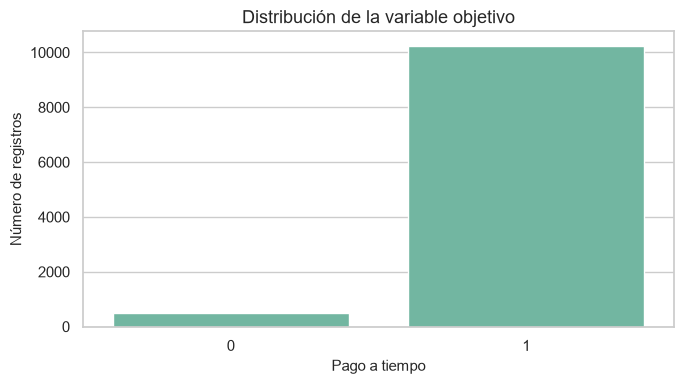

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=analysis_df, x=TARGET_COLUMN, ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Pago a tiempo")
ax.set_ylabel("Número de registros")
plt.tight_layout()
plt.show()

**Interpretación técnica.** El desbalance observado (ratio calculado en
la celda anterior, cercano a 20:1) descarta la exactitud (`accuracy`) como
métrica de evaluación: un modelo que siempre prediga "pago a tiempo" ya
obtendría el baseline calculado arriba sin haber aprendido nada útil. Las
etapas de entrenamiento deberán usar métricas robustas al desbalance
(PR-AUC, recall de la clase minoritaria, F1 o F-beta ponderado), y
considerar `class_weight="balanced"`, sobremuestreo (SMOTE) o ajuste de
umbral de decisión.

## Análisis univariado - variables numéricas

Los histogramas muestran la forma de la distribución de cada variable
numérica. Para evitar generar una figura completa por cada una de las
variables numéricas (lo que en la versión anterior producía cerca de 20
figuras sueltas y dificultaba la lectura del notebook), se consolidan en
una sola grilla mediante una función reutilizable `plot_grid`.

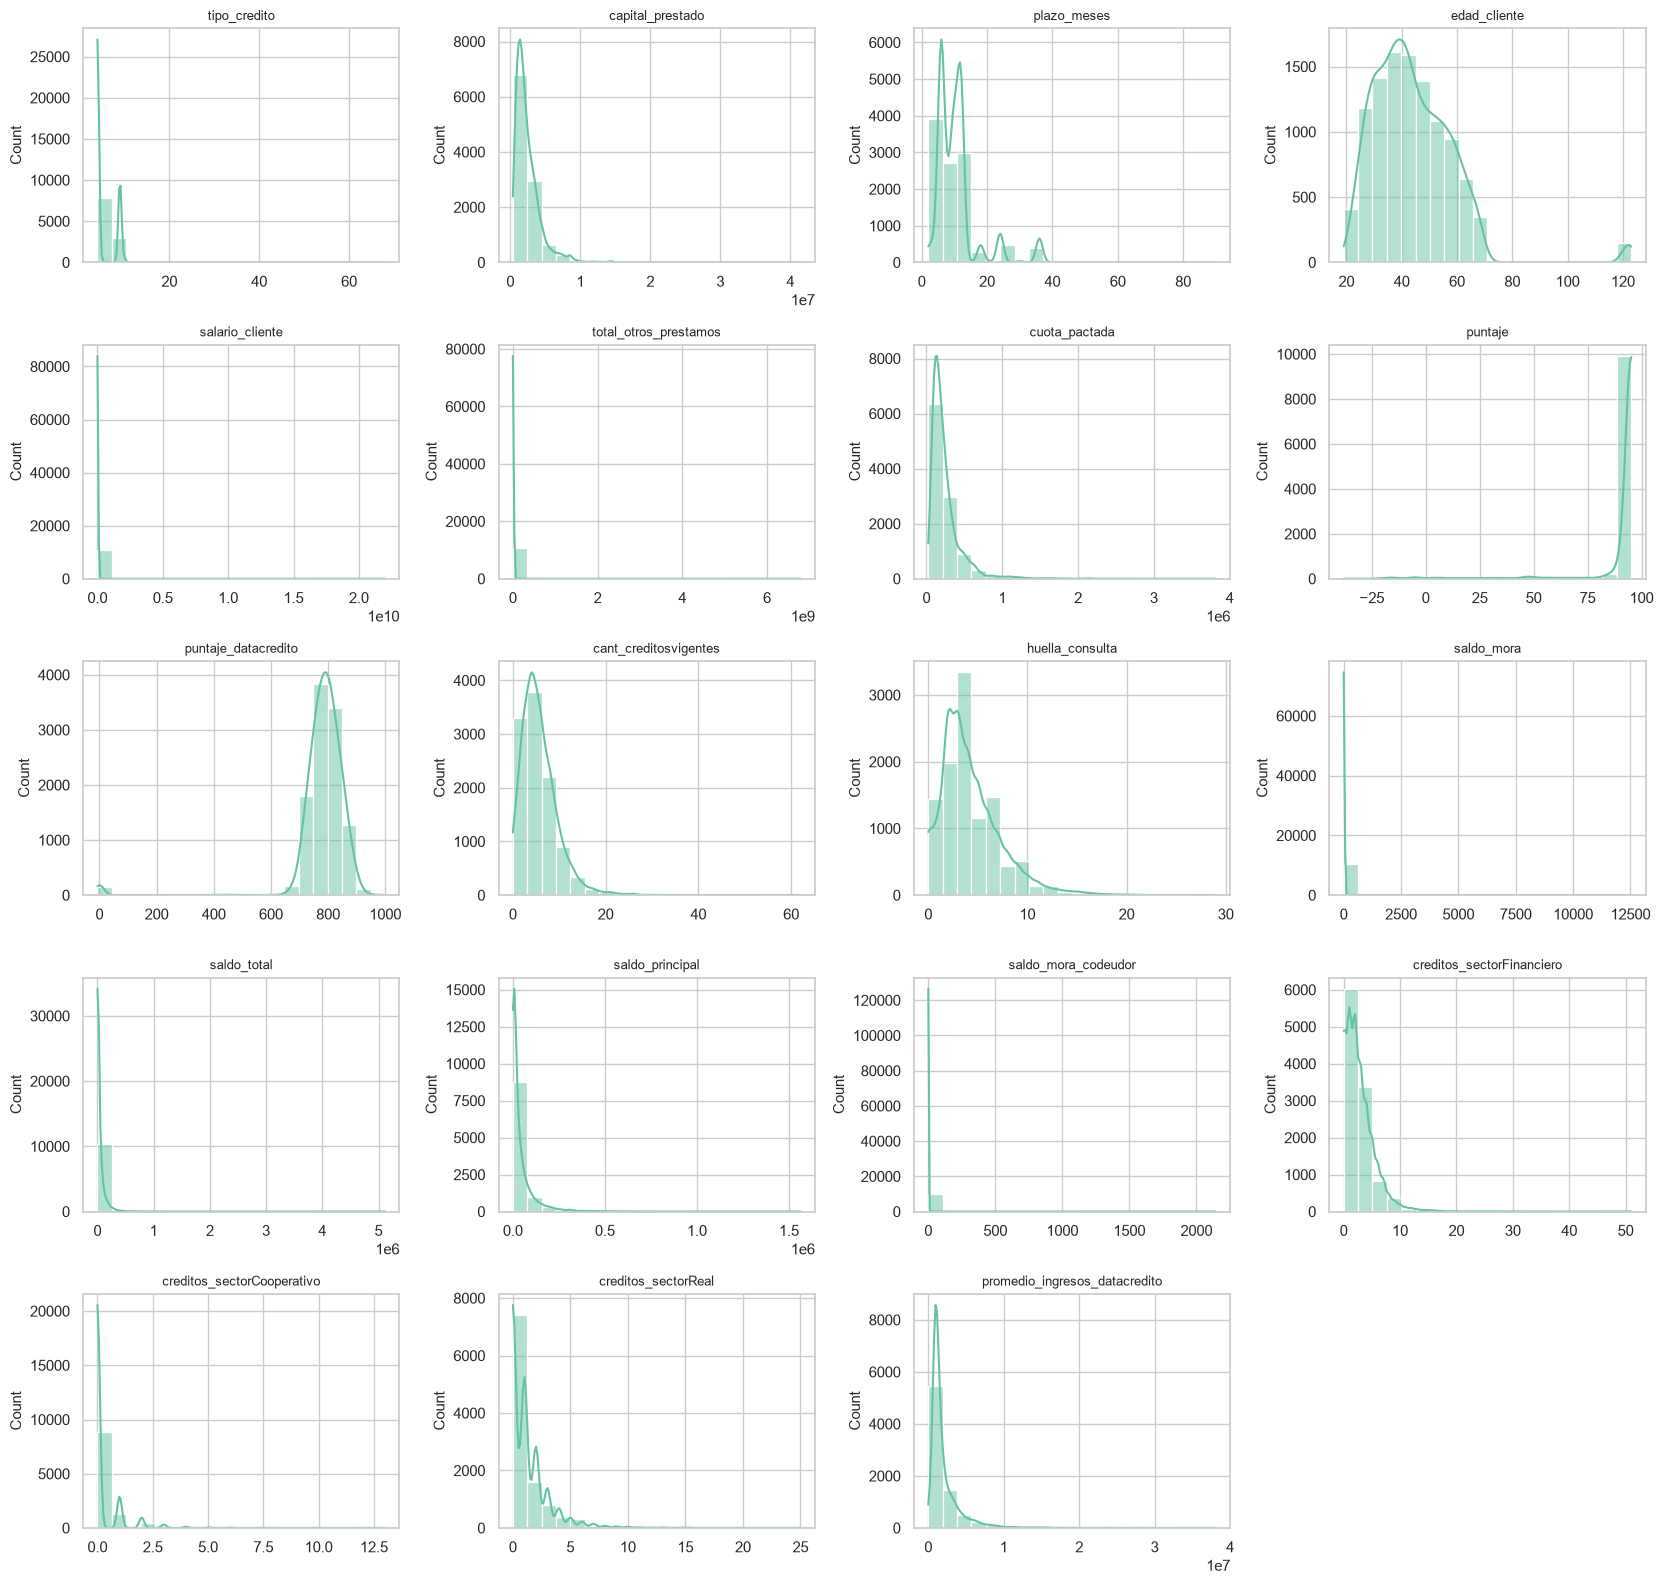

In [40]:
def plot_grid(
    data: pd.DataFrame,
    columns: list[str],
    kind: str = "hist",
    ncols: int = 4,
    target: str | None = None,
) -> plt.Figure:
    """Genera una grilla de subplots para un conjunto de columnas.

    kind admite "hist" (histograma + KDE), "box" (boxplot univariado) o
    "box_target" (boxplot de la variable segmentado por la variable
    objetivo, requiere pasar target).
    """
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, columns):
        if kind == "hist":
            sns.histplot(data=data, x=column, bins=20, kde=True, ax=ax)
        elif kind == "box":
            sns.boxplot(data=data, x=column, ax=ax)
        elif kind == "box_target" and target is not None:
            sns.boxplot(data=data, x=target, y=column, ax=ax)
        ax.set_title(column, fontsize=9)
        ax.set_xlabel("")

    for ax in axes[len(columns):]:
        ax.axis("off")

    plt.tight_layout()
    return fig


fig_hist = plot_grid(analysis_df, numeric_variables, kind="hist")
plt.show()

**Interpretación técnica.** Las variables con `skewness` alto en la tabla
de estadística descriptiva (por ejemplo, variables monetarias y de
saldos) son precisamente las que muestran colas extensas en esta grilla.
Un `skewness` cercano a cero y una forma aproximadamente simétrica en el
histograma son consistentes entre sí; una discrepancia entre ambos
indicaría un error de cálculo que debería revisarse. No se eliminan
valores extremos durante el EDA: en el negocio crediticio, un valor alto
puede ser una observación legítima asociada a mayor exposición.

## Boxplots y valores extremos

Los boxplots permiten visualizar dispersión y posibles valores atípicos
bajo el criterio IQR, consolidados también en una sola grilla. Además del
conteo de valores extremos, se calcula la proporción de la moda por
variable para distinguir un verdadero problema de outliers de una
variable **cuasi-constante** (donde casi cualquier valor distinto del
dominante se marca como "outlier" por el criterio IQR, sin que eso
signifique una anomalía real).

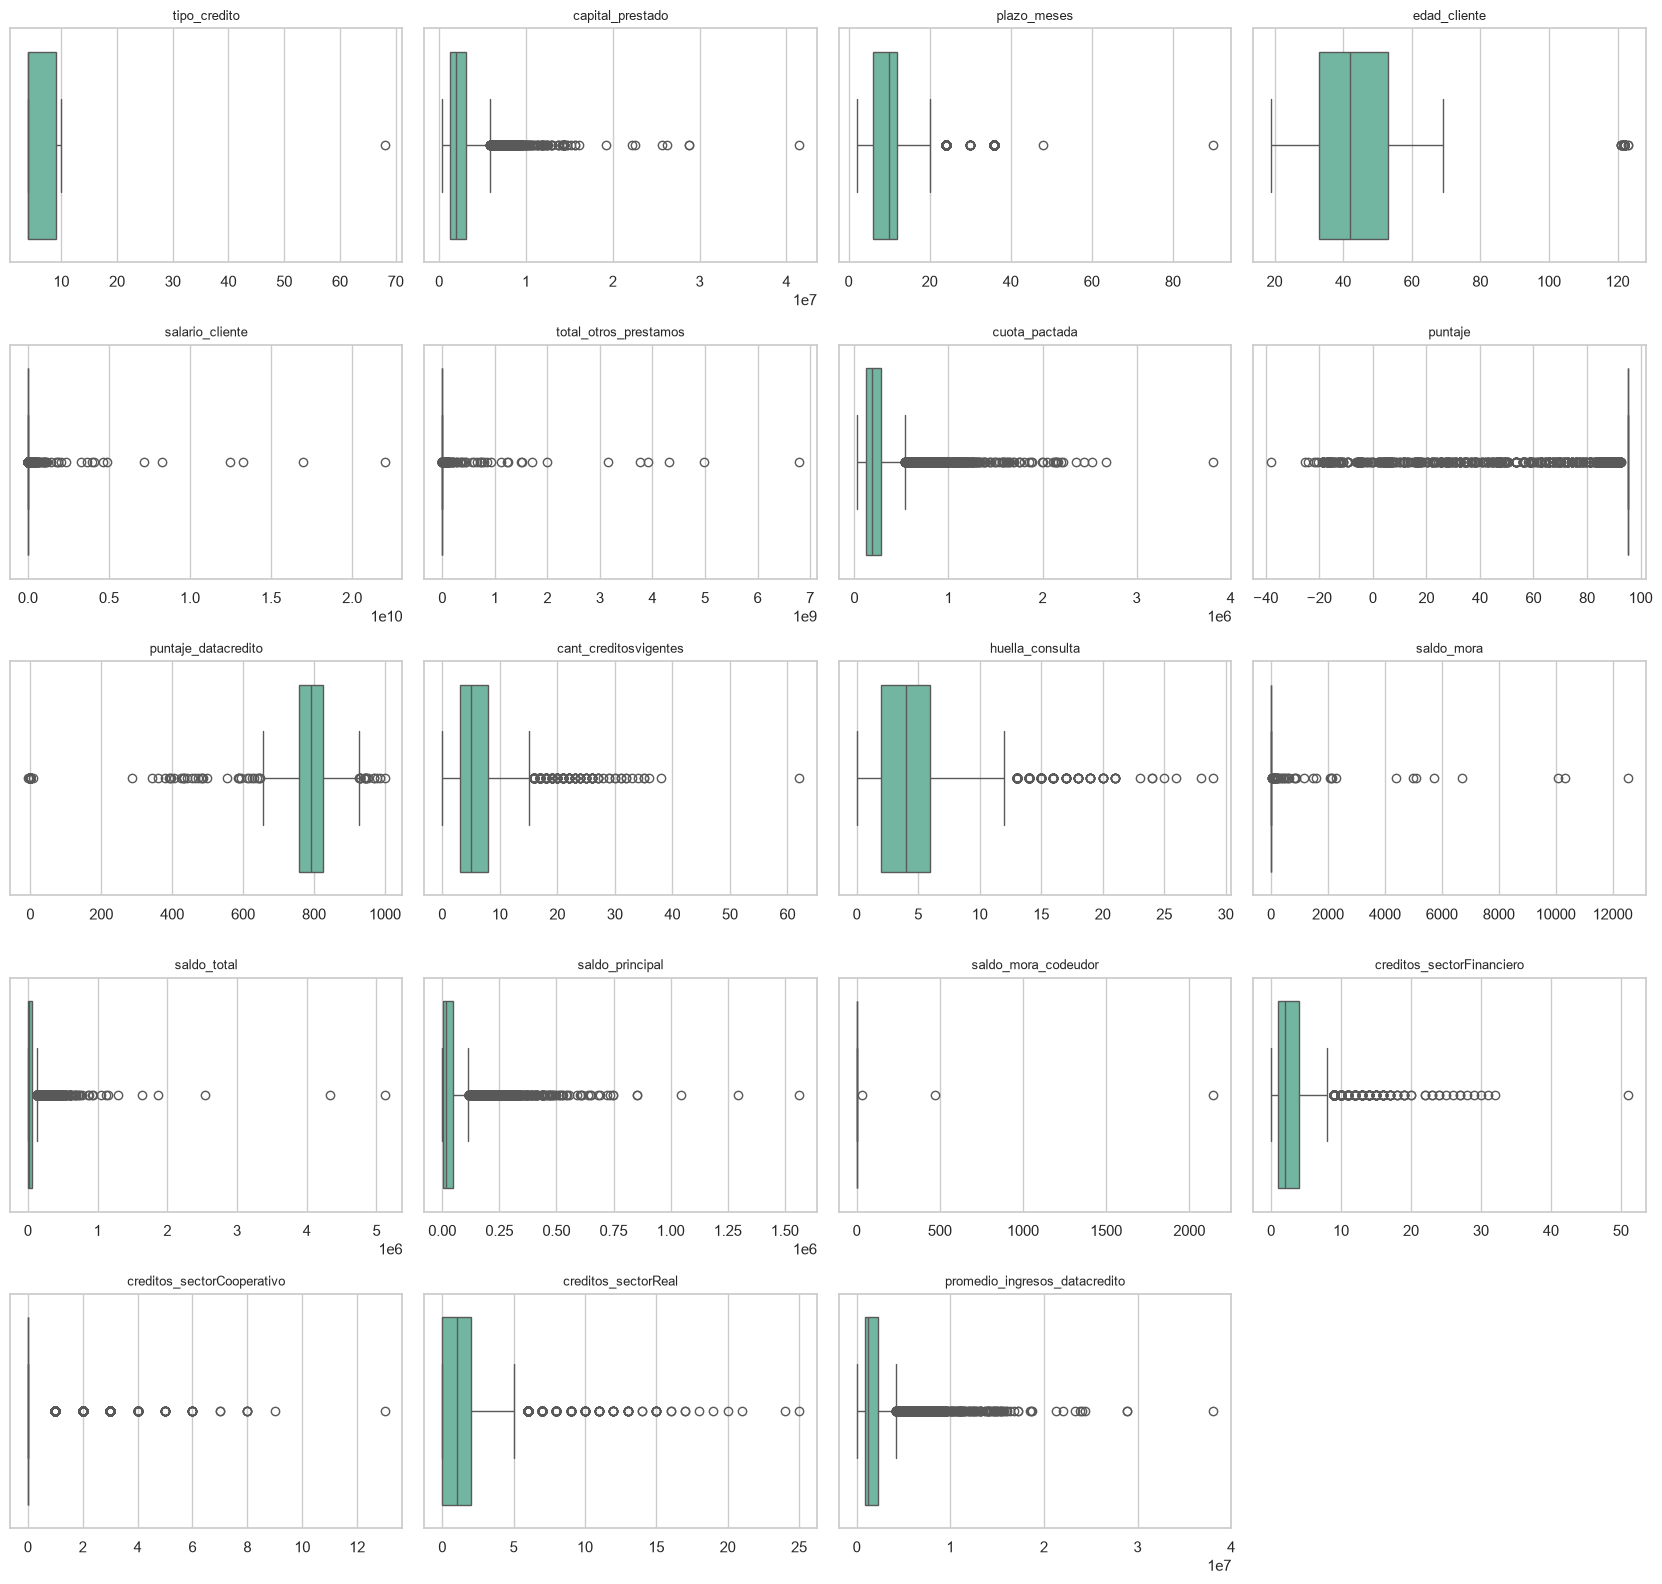

In [41]:
fig_box = plot_grid(analysis_df, numeric_variables, kind="box")
plt.show()

In [42]:
outlier_summary = []
for column in numeric_variables:
    q1_value = analysis_df[column].quantile(0.25)
    q3_value = analysis_df[column].quantile(0.75)
    iqr_value = q3_value - q1_value
    lower_limit = q1_value - 1.5 * iqr_value
    upper_limit = q3_value + 1.5 * iqr_value

    outliers = analysis_df[
        (analysis_df[column] < lower_limit) | (analysis_df[column] > upper_limit)
    ][column]
    moda_proporcion = analysis_df[column].value_counts(normalize=True, dropna=True).max()

    outlier_summary.append(
        {
            "variable": column,
            "limite_inferior": lower_limit,
            "limite_superior": upper_limit,
            "cantidad_valores_extremos": int(outliers.shape[0]),
            "porcentaje": round(outliers.shape[0] / len(analysis_df) * 100, 2),
            "proporcion_moda": round(float(moda_proporcion), 4),
            "cuasi_constante": bool(moda_proporcion > QUASI_CONSTANT_THRESHOLD),
        }
    )

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values(
    "cantidad_valores_extremos", ascending=False
)
outlier_summary_df

,variable,limite_inferior,limite_superior,cantidad_valores_extremos,porcentaje,proporcion_moda,cuasi_constante
16,creditos_sectorCooperativo,0.00,0.00,1895,17.61,0.82,False
7,puntaje,95.23,95.23,1356,12.60,0.87,False
12,saldo_total,-72228.00,128108.00,970,9.01,0.07,False
13,saldo_principal,-64723.38,115045.62,951,8.84,0.06,False
2,plazo_meses,-3.00,21.00,869,8.07,0.31,False
18,promedio_ingresos_datacredito,-1034896.00,4191912.00,784,7.28,0.06,False
6,cuota_pactada,-129146.50,538021.50,765,7.11,0.00,False
4,salario_cliente,-2313712.00,9189520.00,718,6.67,0.08,False
5,total_otros_prestamos,-1750000.00,4250000.00,589,5.47,0.10,False
1,capital_prestado,-1565182.50,5874853.50,550,5.11,0.01,False


**Interpretación técnica.** Las variables marcadas con `cuasi_constante =
True` (proporción de la moda superior al 95%) no deben interpretarse
según el conteo de "valores extremos" del criterio IQR: ese conteo es un
artefacto de tener casi toda la masa de datos en un único valor (por
ejemplo, 0), no una señal de outliers de negocio. Estas variables son
candidatas a baja capacidad predictiva individual y deben evaluarse para
descartarlas o transformarlas en una variable binaria ("tiene / no tiene")
en Feature Engineering. Los valores extremos detectados en variables
genuinamente continuas no se eliminan en este notebook; se documentan para
su evaluación funcional posterior.

## Análisis univariado - variables categóricas

Los countplots permiten revisar frecuencia por categoría y detectar
niveles dominantes o categorías poco frecuentes. Se grafica sobre una
copia local de cada columna (`fillna` + `astype(str)` aplicado solo a la
serie usada para el gráfico), de modo que `analysis_df` **no se modifica**
en ningún momento, en coherencia con el principio declarado en la Celda 1
de que este notebook no imputa valores.

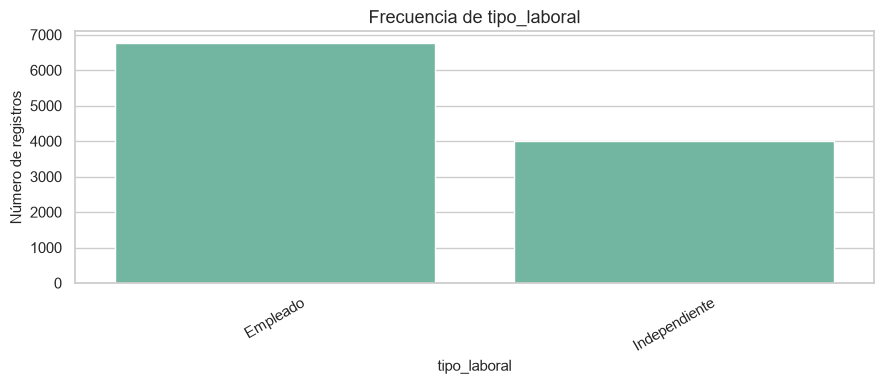

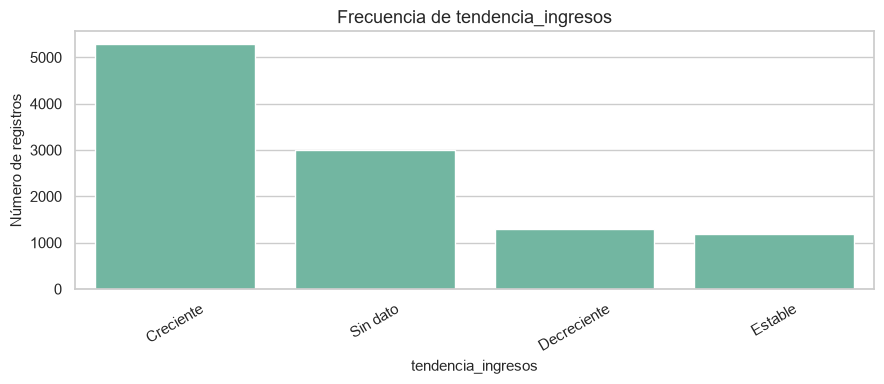

In [43]:
univariate_categorical_plot_columns = {
    column: (
        "tendencia_ingresos_valida" if column == "tendencia_ingresos" else column
    )
    for column in categorical_variables
}

for display_label, source_column in univariate_categorical_plot_columns.items():
    plot_series = analysis_df[source_column].fillna("Sin dato").astype(str)
    order = plot_series.value_counts().index

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.countplot(x=plot_series, order=order, ax=ax)
    ax.set_title(f"Frecuencia de {display_label}")
    ax.set_xlabel(display_label)
    ax.set_ylabel("Número de registros")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


**Interpretación técnica.** Las variables categóricas deben conservarse
como insumos de segmentación si muestran diferencias operativas entre
grupos. Las categorías de baja frecuencia deben evaluarse posteriormente
para evitar codificaciones inestables (por ejemplo, agrupar categorías
raras en una etiqueta `"Otro"` antes de aplicar one-hot encoding).

## Análisis bivariado numérico (con prueba estadística)

El análisis bivariado compara cada variable numérica contra la variable
objetivo. Además del boxplot comparativo, se aplica la prueba de
Mann-Whitney U (no paramétrica, apropiada dado el desbalance de clases y
la ausencia de supuesto de normalidad) para cuantificar si la diferencia
observada entre grupos es estadísticamente significativa, en vez de
apoyarse únicamente en la inspección visual.

INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using ca

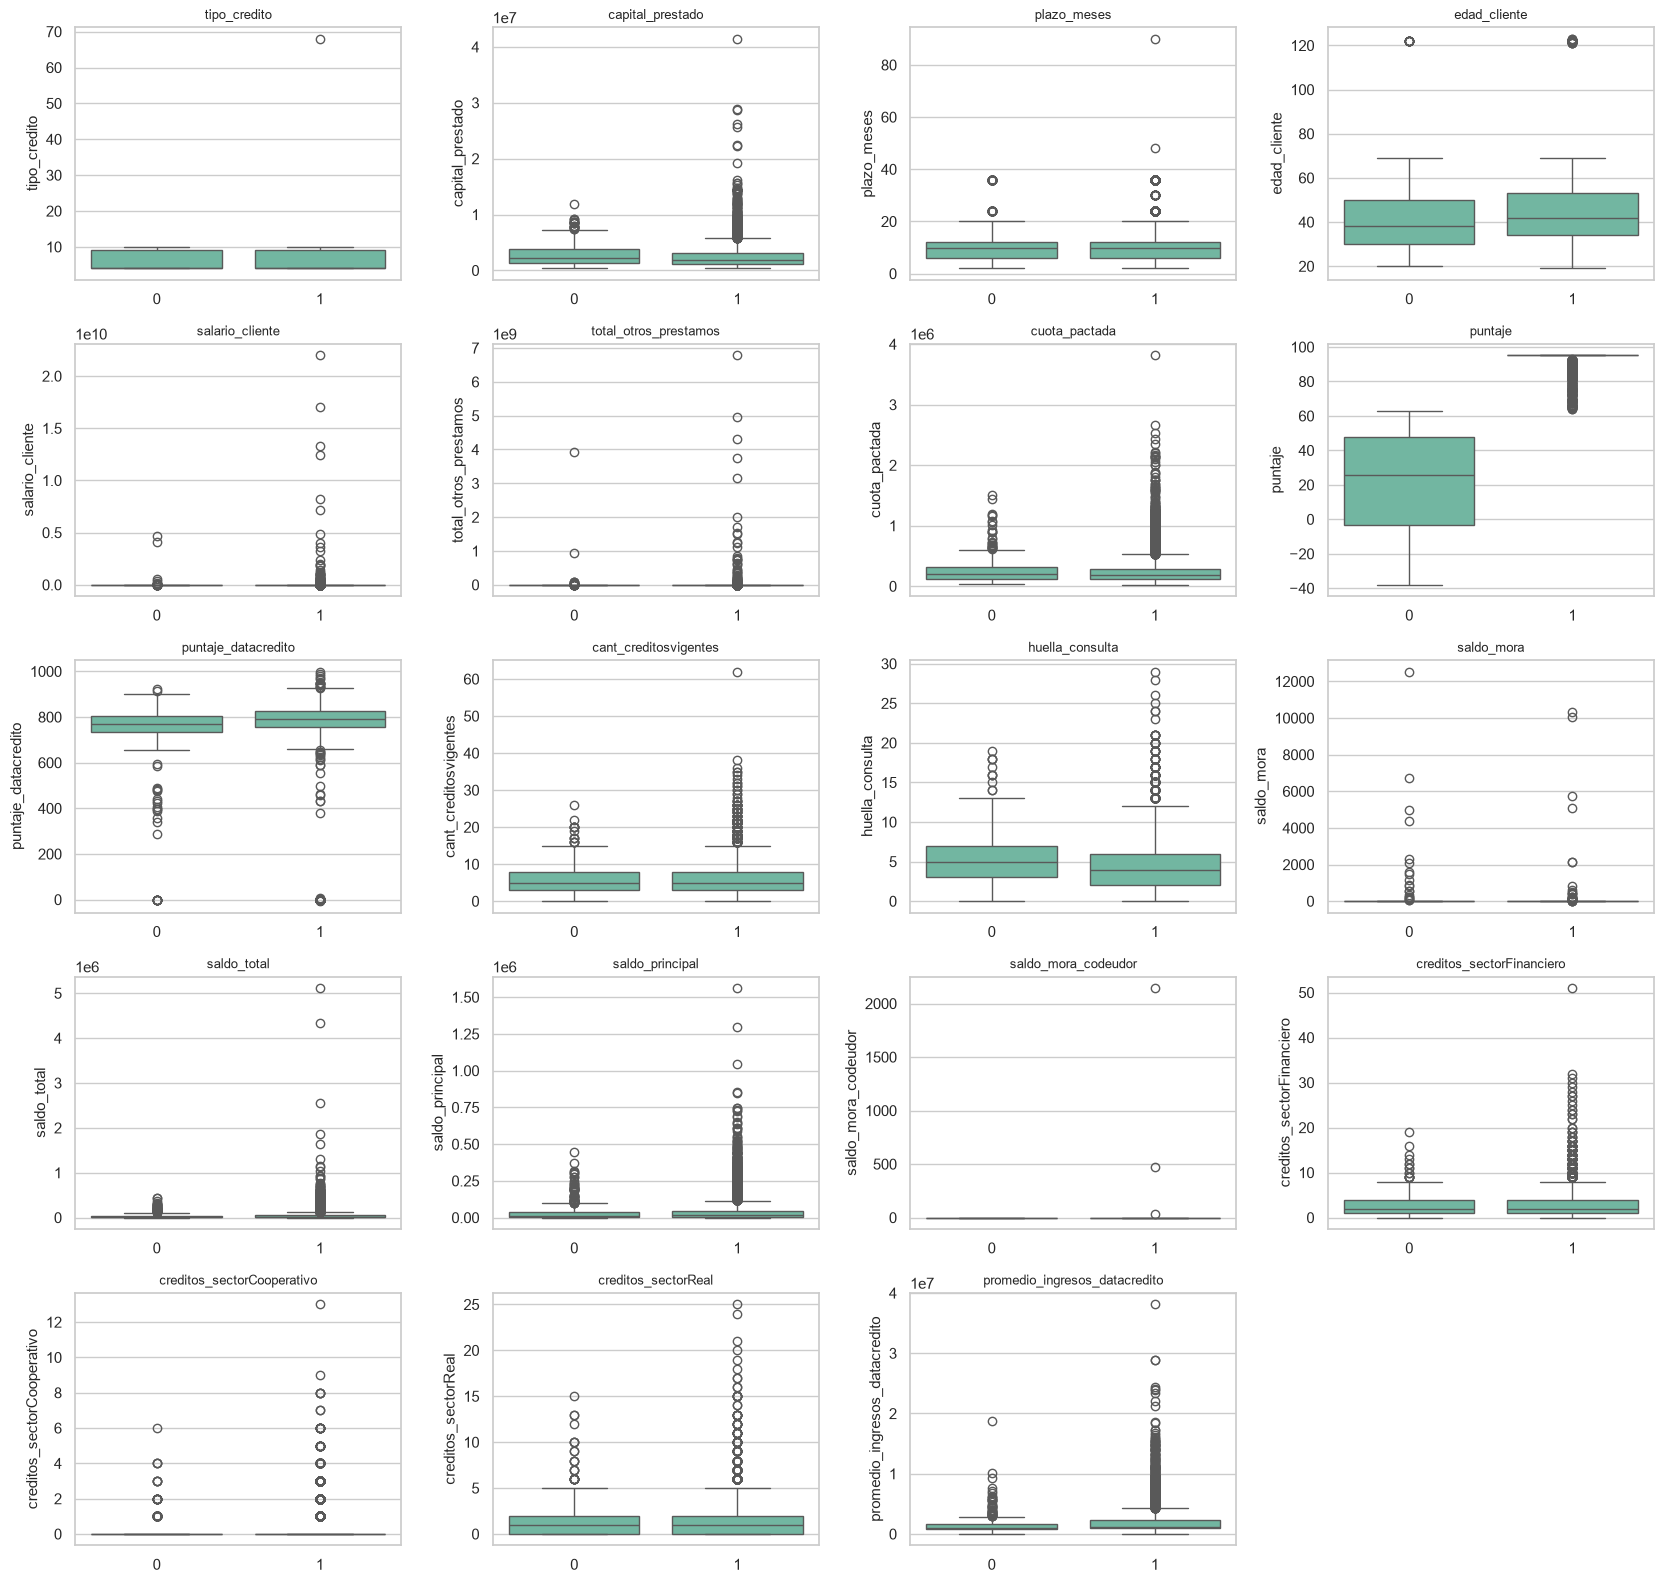

In [44]:
selected_numeric_variables = [c for c in numeric_variables if c != TARGET_COLUMN]

fig_box_target = plot_grid(
    analysis_df, selected_numeric_variables, kind="box_target", target=TARGET_COLUMN
)
plt.show()

In [45]:
bivariate_tests = []
for column in selected_numeric_variables:
    group_0 = analysis_df.loc[analysis_df[TARGET_COLUMN] == 0, column].dropna()
    group_1 = analysis_df.loc[analysis_df[TARGET_COLUMN] == 1, column].dropna()
    if len(group_0) > 0 and len(group_1) > 0:
        statistic, p_value = stats.mannwhitneyu(
            group_0, group_1, alternative="two-sided"
        )
        bivariate_tests.append(
            {
                "variable": column,
                "estadistico_U": statistic,
                "p_value": p_value,
                "significativo_0_05": p_value < 0.05,
            }
        )

bivariate_tests_df = pd.DataFrame(bivariate_tests).sort_values("p_value")
bivariate_tests_df

,variable,estadistico_U,p_value,significativo_0_05
7,puntaje,0.00,0.00,True
11,saldo_mora,2619219.00,0.00,True
8,puntaje_datacredito,1969716.50,0.00,True
10,huella_consulta,3133577.50,0.00,True
3,edad_cliente,2257181.50,0.00,True
18,promedio_ingresos_datacredito,1098071.50,0.00,True
1,capital_prestado,2917963.00,0.00,True
15,creditos_sectorFinanciero,2406628.50,0.00,True
5,total_otros_prestamos,2433957.00,0.01,True
16,creditos_sectorCooperativo,2504005.00,0.01,True


**Interpretación técnica.** Las variables con `significativo_0_05 = True`
son las candidatas reales a aportar señal predictiva según evidencia
estadística, no solo apreciación visual del boxplot. Un p-valor bajo con
una diferencia visual pequeña puede deberse al tamaño de muestra (10.763
registros); por eso el hallazgo estadístico debe complementarse siempre
con el tamaño del efecto, no solo con la significancia.

## Análisis bivariado categórico (con chi-cuadrado)

Se evalúa la asociación entre cada variable categórica y la variable
objetivo con una prueba de chi-cuadrado de independencia sobre la tabla de
contingencia. Para `tendencia_ingresos` se utiliza exclusivamente la
versión depurada `tendencia_ingresos_valida`: ejecutar este análisis sobre
la columna contaminada generaría categorías espurias de un solo registro
con 100% de una clase, lo cual no es señal real sino ruido (este era
exactamente el problema de la versión anterior del notebook).

In [46]:
chi2_results = []
bivariate_categorical_columns = [
    univariate_categorical_plot_columns[c] for c in categorical_variables
]

for column in bivariate_categorical_columns:
    crosstab_counts = pd.crosstab(analysis_df[column], analysis_df[TARGET_COLUMN])
    chi2, p_value, dof, _ = stats.chi2_contingency(crosstab_counts)
    chi2_results.append(
        {
            "variable": column,
            "chi2": chi2,
            "grados_libertad": dof,
            "p_value": p_value,
            "significativo_0_05": p_value < 0.05,
        }
    )

    crosstab_percent = pd.crosstab(
        analysis_df[column], analysis_df[TARGET_COLUMN], normalize="index"
    ) * 100
    display(crosstab_percent.round(2))

chi2_results_df = pd.DataFrame(chi2_results)
chi2_results_df

Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29,95.71
Independiente,5.51,94.49


Pago_atiempo,0,1
tendencia_ingresos_valida,,
Creciente,3.91,96.09
Decreciente,6.27,93.73
Estable,4.63,95.37


,variable,chi2,grados_libertad,p_value,significativo_0_05
0,tipo_laboral,8.00,1,0.00,True
1,tendencia_ingresos_valida,13.91,2,0.00,True


**Interpretación técnica.** Un resultado significativo en la prueba de
chi-cuadrado indica que la distribución del target difiere entre
categorías de forma poco probable por azar; esto convierte a la variable
en candidata prioritaria para codificación en Feature Engineering. Un
resultado no significativo no descarta la variable por completo, pero
reduce su prioridad frente a otras con evidencia estadística más fuerte.

## Correlaciones bivariadas

La matriz de correlación resume relaciones lineales de a pares entre
variables numéricas. Se renombra esta sección de "análisis multivariado"
(nombre usado en la versión anterior) a "correlaciones bivariadas", porque
una matriz de correlación de a pares es, en sentido estricto, un análisis
bivariado repetido sobre múltiples pares de variables, no un análisis
multivariado. El verdadero análisis multivariado (multicolinealidad vía
VIF) se desarrolla en una sección separada más adelante.

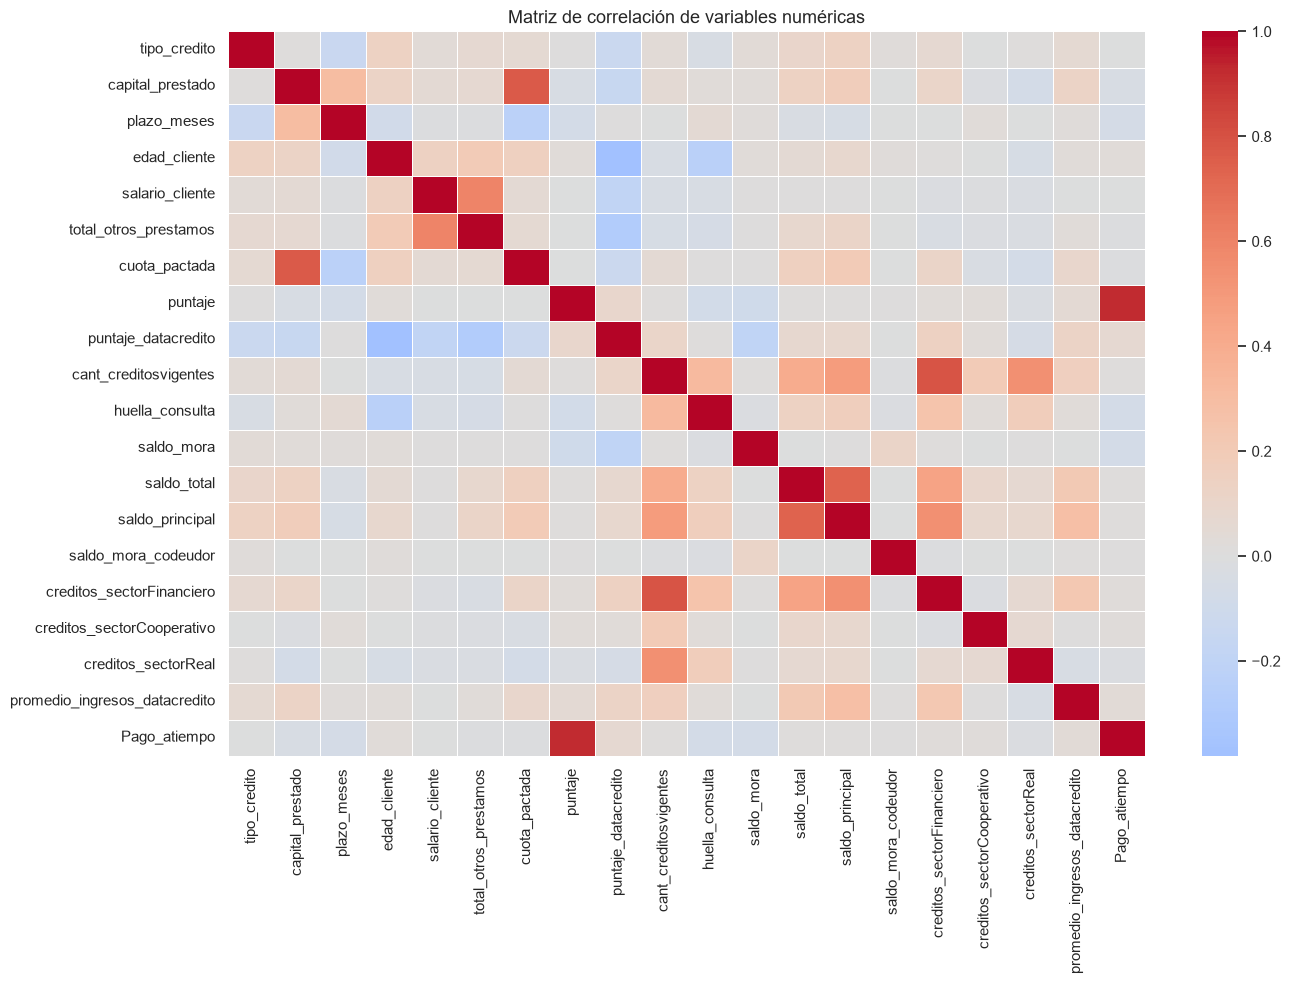

In [47]:
correlation_matrix = analysis_df[numeric_variables + [TARGET_COLUMN]].corr(
    numeric_only=True
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlation_matrix, cmap="coolwarm", center=0, linewidths=0.5, annot=False, ax=ax
)
ax.set_title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

In [48]:
target_correlations = (
    correlation_matrix[TARGET_COLUMN]
    .drop(labels=[TARGET_COLUMN], errors="ignore")
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "variable", TARGET_COLUMN: "correlacion_objetivo"})
)

leakage_flags = target_correlations[
    target_correlations["correlacion_objetivo"].abs() > LEAKAGE_CORRELATION_THRESHOLD
]

print(target_correlations)
print("Variables con posible fuga de información (|corr| > 0.70):")
print(leakage_flags)

                         variable  correlacion_objetivo
0                         puntaje                  0.92
1                 huella_consulta                 -0.07
2                      saldo_mora                 -0.07
3             puntaje_datacredito                  0.07
4                     plazo_meses                 -0.06
5                capital_prestado                 -0.04
6   promedio_ingresos_datacredito                  0.04
7                    edad_cliente                  0.03
8             creditos_sectorReal                 -0.02
9       creditos_sectorFinanciero                  0.02
10     creditos_sectorCooperativo                  0.02
11                    saldo_total                  0.01
12                  cuota_pactada                 -0.01
13                saldo_principal                  0.01
14          total_otros_prestamos                 -0.01
15          cant_creditosvigentes                  0.01
16                salario_cliente               

**Interpretación técnica — alerta de posible fuga de información.** La
variable `puntaje` presenta una correlación de aproximadamente **0.92**
con la variable objetivo. Este valor es atípicamente alto para un
predictor individual en un problema real de riesgo crediticio, y es la
señal más importante de todo el análisis de correlaciones: sugiere que
`puntaje` podría calcularse, total o parcialmente, a partir de información
posterior al desembolso o del propio comportamiento histórico de pago del
cliente (a diferencia de `puntaje_datacredito`, que es un score externo de
buró). **Antes de usar esta variable en el modelado, debe confirmarse con
el equipo de datos/negocio cómo se calcula `puntaje` y en qué momento del
proceso crediticio está disponible.** Si se confirma que incorpora
información no disponible en el momento de la predicción (por ejemplo, si
se calcula después de observar si el cliente pagó a tiempo), la variable
debe excluirse del modelado por fuga de información. El resto de
correlaciones numéricas con el target son bajas, lo que es consistente con
un problema de riesgo crediticio real, donde las relaciones suelen ser no
lineales o de interacción entre variables.

## Análisis multivariado: multicolinealidad (VIF)

A diferencia de la matriz de correlación bivariada, el Factor de Inflación
de la Varianza (VIF) evalúa cuánta varianza de cada predictor numérico es
explicada por una combinación lineal del resto de predictores, es decir,
sí constituye un análisis genuinamente multivariado. Un VIF alto (regla
práctica: mayor a 5-10) indica redundancia entre variables predictoras,
relevante para modelos lineales y para decisiones de selección de
variables independientemente del algoritmo final.

In [49]:
if HAS_STATSMODELS:
    vif_input = analysis_df[numeric_variables].dropna()
    vif_rows_retained_pct = round(len(vif_input) / len(analysis_df) * 100, 2)
    logger.info(
        "VIF calculado sobre %s de %s registros (%s%% ), tras eliminar filas "
        "con nulos en alguna variable numerica.",
        len(vif_input), len(analysis_df), vif_rows_retained_pct,
    )
    if vif_rows_retained_pct < 80:
        logger.warning(
            "El calculo de VIF descarta mas del 20%% de los registros por "
            "nulos combinados; interpretar el resultado con cautela."
        )
    vif_data = pd.DataFrame(
        {
            "variable": numeric_variables,
            "VIF": [
                variance_inflation_factor(vif_input.values, i)
                for i in range(len(numeric_variables))
            ],
        }
    ).sort_values("VIF", ascending=False)
else:
    logger.warning(
        "statsmodels no está instalado en este entorno; instalar con "
        "`pip install statsmodels` para calcular VIF."
    )
    vif_data = pd.DataFrame(columns=["variable", "VIF"])
    vif_rows_retained_pct = None

vif_data


INFO | VIF calculado sobre 7673 de 10763 registros (71.29% ), tras eliminar filas con nulos en alguna variable numerica.
WARNING | El calculo de VIF descarta mas del 20%% de los registros por nulos combinados; interpretar el resultado con cautela.


,variable,VIF
8,puntaje_datacredito,68.63
7,puntaje,33.90
9,cant_creditosvigentes,32.71
3,edad_cliente,16.93
15,creditos_sectorFinanciero,15.43
1,capital_prestado,15.00
6,cuota_pactada,12.09
2,plazo_meses,8.80
0,tipo_credito,6.53
17,creditos_sectorReal,4.72


**Interpretación técnica.** Las variables con VIF elevado son redundantes
entre sí y aportan información solapada al modelo; para algoritmos
lineales o basados en distancia, es razonable eliminar una de cada par
altamente colineal o aplicar regularización (Ridge/Lasso). Para modelos de
árboles/boosting, la multicolinealidad afecta menos al desempeño
predictivo, pero sí distorsiona la interpretación de importancia de
variables, por lo que este resultado debe documentarse igualmente para la
etapa de interpretabilidad del modelo.

## Reglas de validación de datos

Las reglas siguientes documentan controles recomendados para producción,
derivados directamente de los hallazgos de este notebook (no son reglas
genéricas de manual). No modifican el dataset en este notebook; sirven
como contrato de calidad para etapas posteriores del pipeline.

Antes de declarar la regla de "variables monetarias no negativas", se cuantifica explícitamente cuántos registros la violan hoy, en lugar de documentar la regla sin evidencia de si aplica al dataset actual.

In [50]:
monetary_columns = [
    "capital_prestado", "salario_cliente", "cuota_pactada",
    "saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor",
]
monetary_columns = [c for c in monetary_columns if c in analysis_df.columns]

negative_values_summary = []
for column in monetary_columns:
    negatives = analysis_df[analysis_df[column] < 0][column]
    negative_values_summary.append(
        {
            "variable": column,
            "valores_negativos": int(negatives.shape[0]),
            "porcentaje": round(negatives.shape[0] / len(analysis_df) * 100, 2),
        }
    )
negative_values_df = pd.DataFrame(negative_values_summary).sort_values(
    "valores_negativos", ascending=False
)
display(negative_values_df)

validation_rules = pd.DataFrame(
    [
        {
            "regla": "El archivo oficial debe existir antes de ejecutar el pipeline.",
            "variables": "Base_de_datos.xlsx - Hoja1.csv",
        },
        {
            "regla": "edad_cliente debe estar en el rango [18, 100].",
            "variables": "edad_cliente",
        },
        {
            "regla": "puntaje debe estar en el rango [0, 100].",
            "variables": "puntaje",
        },
        {
            "regla": "puntaje_datacredito debe estar en el rango [150, 950].",
            "variables": "puntaje_datacredito",
        },
        {
            "regla": (
                "tendencia_ingresos solo debe contener las categorías "
                "Creciente, Decreciente o Estable; cualquier otro valor "
                "indica corrupción de datos y debe reportarse a la fuente."
            ),
            "variables": "tendencia_ingresos",
        },
        {
            "regla": (
                "puntaje debe validarse como posible fuente de fuga de "
                "información antes de habilitarse para el modelado."
            ),
            "variables": "puntaje",
        },
        {
            "regla": "Las variables monetarias y de saldos no deben ser negativas salvo justificación funcional.",
            "variables": "capital_prestado, salario_cliente, cuota_pactada, saldos",
        },
        {
            "regla": "La variable objetivo debe contener únicamente clases válidas y documentadas.",
            "variables": TARGET_COLUMN,
        },
        {
            "regla": "Los nulos deben tratarse con reglas reproducibles en Feature Engineering.",
            "variables": "variables con porcentaje_nulos mayor a cero",
        },
    ]
)
validation_rules

,variable,valores_negativos,porcentaje
0,capital_prestado,0,0.00
1,salario_cliente,0,0.00
2,cuota_pactada,0,0.00
3,saldo_mora,0,0.00
4,saldo_total,0,0.00
5,saldo_principal,0,0.00
6,saldo_mora_codeudor,0,0.00


,regla,variables
0,El archivo oficial debe existir antes de ejecu...,Base_de_datos.xlsx - Hoja1.csv
1,"edad_cliente debe estar en el rango [18, 100].",edad_cliente
2,"puntaje debe estar en el rango [0, 100].",puntaje
3,puntaje_datacredito debe estar en el rango [15...,puntaje_datacredito
4,tendencia_ingresos solo debe contener las cate...,tendencia_ingresos
5,puntaje debe validarse como posible fuente de ...,puntaje
6,Las variables monetarias y de saldos no deben ...,"capital_prestado, salario_cliente, cuota_pacta..."
7,La variable objetivo debe contener únicamente ...,Pago_atiempo
8,Los nulos deben tratarse con reglas reproducib...,variables con porcentaje_nulos mayor a cero


## Transformaciones sugeridas para Feature Engineering

Las recomendaciones se registran para el siguiente avance sin ejecutarlas
aquí. Esta separación evita mezclar comprensión de datos con preparación
de variables, y prioriza explícitamente los hallazgos críticos de este
notebook.

In [51]:
feature_engineering_recommendations = pd.DataFrame(
    [
        {
            "prioridad": "crítica",
            "recomendacion": (
                "Confirmar con negocio/fuente de datos el método de cálculo "
                "de puntaje antes de habilitarlo como predictor (riesgo de "
                "fuga de información, correlación 0.92 con el target)."
            ),
        },
        {
            "prioridad": "crítica",
            "recomendacion": (
                "Reconstruir o reingestar tendencia_ingresos en la fuente; "
                "mientras tanto, usar únicamente tendencia_ingresos_valida."
            ),
        },
        {
            "prioridad": "alta",
            "recomendacion": (
                "Definir reglas de corrección o exclusión para los registros "
                "fuera de rango en edad_cliente, puntaje y puntaje_datacredito."
            ),
        },
        {
            "prioridad": "alta",
            "recomendacion": (
                "Definir estrategia de balanceo (class_weight, SMOTE o ajuste "
                "de umbral) dado el ratio de desbalance ~20:1 del target."
            ),
        },
        {
            "prioridad": "media",
            "recomendacion": "Convertir fecha_prestamo a formato datetime.",
        },
        {
            "prioridad": "media",
            "recomendacion": "Definir tratamiento de nulos por variable según significado de negocio.",
        },
        {
            "prioridad": "media",
            "recomendacion": "Codificar variables categóricas con estrategia reproducible.",
        },
        {
            "prioridad": "media",
            "recomendacion": "Evaluar descarte o binarización de variables cuasi-constantes (ver outlier_summary_df).",
        },
        {
            "prioridad": "baja",
            "recomendacion": "Escalar variables monetarias y de saldos si el modelo lo requiere.",
        },
    ]
)
feature_engineering_recommendations

,prioridad,recomendacion
0,crítica,Confirmar con negocio/fuente de datos el métod...
1,crítica,Reconstruir o reingestar tendencia_ingresos en...
2,alta,Definir reglas de corrección o exclusión para ...
3,alta,"Definir estrategia de balanceo (class_weight, ..."
4,media,Convertir fecha_prestamo a formato datetime.
5,media,Definir tratamiento de nulos por variable segú...
6,media,Codificar variables categóricas con estrategia...
7,media,Evaluar descarte o binarización de variables c...
8,baja,Escalar variables monetarias y de saldos si el...


## Conclusiones técnicas y de negocio

El dataset contiene 10.763 registros y 23 variables crediticias, laborales, financieras y de comportamiento de pago, sin duplicados
exactos. La variable objetivo es `Pago_atiempo`; no existe una columna `churn` en la fuente, por lo que el análisis no la inventa ni la deriva.

**El target presenta un desbalance severo (ratio ≈ 20:1, baseline trivial ≈ 95%)**, lo que descarta accuracy como métrica de evaluación y exige métricas robustas al desbalance, además de una estrategia explícita de balanceo antes del entrenamiento.

Se identificaron tres hallazgos críticos que deben resolverse antes de Feature Engineering y que condicionan directamente la validez del modelo final:

1. **Posible fuga de información en `puntaje`** (correlación de 0.92 con    el target): debe confirmarse con el equipo de datos si esta variable incorpora información posterior al evento que se busca predecir. Si es así, debe excluirse del modelado.
2. **Corrupción de datos en `tendencia_ingresos`**: la columna mezcla Categorías válidas con valores numéricos aislados. Se aisló en   `tendencia_ingresos_valida` para no generar señales espurias en el análisis bivariado, pero requiere reconstrucción en la fuente.
3. **Valores fuera de rango válido** en `edad_cliente`, `puntaje` y `puntaje_datacredito`, cuantificados explícitamente y documentados como reglas de validación para producción.

Las variables financieras y de saldos muestran valores extremos compatibles con la operación crediticia y no se eliminan en esta etapa; se documentan para revisión funcional. Las correlaciones lineales con el target, fuera del caso de puntaje, son bajas, lo cual es consistente con la posible existencia de relaciones no lineales o interacciones entre variables, características frecuentes en problemas de riesgo crediticio. Estos hallazgos sugieren que modelos capaces de capturar relaciones no lineales, como los basados en árboles o técnicas de boosting, podrían ofrecer un mejor desempeño que modelos lineales simples; esta hipótesis será evaluada durante la etapa de modelado. El análisis de VIF identifica además las variables numéricas con mayor redundancia entre sí, información relevante tanto para la selección de variables como para la interpretación de la importancia de las características en el modelo final.